In [2]:
import pandas as pd
import numpy as np

In [10]:


a = pd.Series(['zxb', 23, '20020922'])
print(a)

0         zxb
1          23
2    20020922
dtype: object


In [11]:
b = pd.date_range('20260101',periods=6)
print(b)
# 二维加标签
df = pd.DataFrame(np.random.randn(6,4),index=b, columns=['a','b','c','d'])
print(df)

print(df.dtypes)
print(df.index)
print(df.columns)
print(df.values)

DatetimeIndex(['2026-01-01', '2026-01-02', '2026-01-03', '2026-01-04',
               '2026-01-05', '2026-01-06'],
              dtype='datetime64[ns]', freq='D')
                   a         b         c         d
2026-01-01 -0.004687  1.356863 -0.455985  0.120926
2026-01-02  0.004799  1.230878  0.743051  0.762710
2026-01-03  0.893114  2.207601 -0.139985  1.864856
2026-01-04  1.467660 -0.256059  1.084003 -0.943447
2026-01-05 -0.158458  1.260749 -1.516100  0.629837
2026-01-06  0.438929 -0.640629  1.355012 -0.026672
a    float64
b    float64
c    float64
d    float64
dtype: object
DatetimeIndex(['2026-01-01', '2026-01-02', '2026-01-03', '2026-01-04',
               '2026-01-05', '2026-01-06'],
              dtype='datetime64[ns]', freq='D')
Index(['a', 'b', 'c', 'd'], dtype='object')
[[-0.00468651  1.35686252 -0.45598505  0.12092586]
 [ 0.00479908  1.23087818  0.74305148  0.76270955]
 [ 0.89311393  2.2076006  -0.13998506  1.86485602]
 [ 1.46766023 -0.25605925  1.08400336 -0.94344688]
 [-

In [12]:
print(df.describe())

              a         b         c         d
count  6.000000  6.000000  6.000000  6.000000
mean   0.440226  0.859900  0.178333  0.401368
std    0.633513  1.082453  1.086141  0.937545
min   -0.158458 -0.640629 -1.516100 -0.943447
25%   -0.002315  0.115675 -0.376985  0.010228
50%    0.221864  1.245814  0.301533  0.375381
75%    0.779568  1.332834  0.998765  0.729491
max    1.467660  2.207601  1.355012  1.864856


In [13]:
df.sort_values(by='a')

,a,b,c,d
2026-01-05,-0.158458,1.260749,-1.516100,0.629837
2026-01-01,-0.004687,1.356863,-0.455985,0.120926
2026-01-02,0.004799,1.230878,0.743051,0.762710
2026-01-06,0.438929,-0.640629,1.355012,-0.026672
2026-01-03,0.893114,2.207601,-0.139985,1.864856
2026-01-04,1.467660,-0.256059,1.084003,-0.943447


## 选择数据

In [15]:
dates = pd.date_range('20260101',periods=6)
# 二维加标签
df = pd.DataFrame(np.arange(24).reshape((6,4)),index=dates, columns=['A','B','C','D'])

print(df.A, df['A'])
print(df[0:3], df['2026-01-01':'2026-01-03'])

2026-01-01     0
2026-01-02     4
2026-01-03     8
2026-01-04    12
2026-01-05    16
2026-01-06    20
Freq: D, Name: A, dtype: int64 2026-01-01     0
2026-01-02     4
2026-01-03     8
2026-01-04    12
2026-01-05    16
2026-01-06    20
Freq: D, Name: A, dtype: int64
            A  B   C   D
2026-01-01  0  1   2   3
2026-01-02  4  5   6   7
2026-01-03  8  9  10  11             A  B   C   D
2026-01-01  0  1   2   3
2026-01-02  4  5   6   7
2026-01-03  8  9  10  11


In [20]:
# select by label
print(df.loc['2026-01-01'])

print(df.loc['2026-01-02', ['A', 'C']])

print(df.loc[:,'A':'C'])

A    0
B    1
C    2
D    3
Name: 2026-01-01 00:00:00, dtype: int64
A    4
C    6
Name: 2026-01-02 00:00:00, dtype: int64
             A   B   C
2026-01-01   0   1   2
2026-01-02   4   5   6
2026-01-03   8   9  10
2026-01-04  12  13  14
2026-01-05  16  17  18
2026-01-06  20  21  22


In [27]:
# select by index
print(df.iloc[3])
print(df.iloc[3, 2])

print(df.iloc[[1,3],[2,3]])

print(df.iloc[3:5, 1:3])

A    12
B    13
C    14
D    15
Name: 2026-01-04 00:00:00, dtype: int64
14
             C   D
2026-01-02   6   7
2026-01-04  14  15
             B   C
2026-01-04  13  14
2026-01-05  17  18


In [30]:
print(df[df.A > 8])

             A   B   C   D
2026-01-04  12  13  14  15
2026-01-05  16  17  18  19
2026-01-06  20  21  22  23


## 设置值

In [39]:
df.iloc[2,2]=111
df.loc['2026-01-01','C']=222
#df.A[df.A>8]=8 # 不安全，建议采用单步赋值
df['E']=np.nan
df['F']=pd.Series([1,2,3,4,5,6],index=pd.date_range('2026-01-01', periods=6))

print(df)

            A   B    C   D   E  F
2026-01-01  0   1  222   3 NaN  1
2026-01-02  4   5    6   7 NaN  2
2026-01-03  8   9  111  11 NaN  3
2026-01-04  8  13   14  15 NaN  4
2026-01-05  8  17   18  19 NaN  5
2026-01-06  8  21   22  23 NaN  6


## 处理丢失数据

In [40]:
df.dropna(axis=0, how='any') # 当行中有一个位 nan 时 删除整个行

print(df.isnull()) # 缺失数据显示true

print(np.any(df.isnull()) == True)

                A      B      C      D     E      F
2026-01-01  False  False  False  False  True  False
2026-01-02  False  False  False  False  True  False
2026-01-03  False  False  False  False  True  False
2026-01-04  False  False  False  False  True  False
2026-01-05  False  False  False  False  True  False
2026-01-06  False  False  False  False  True  False
True


## 读文件

In [ ]:
data=pd.read_csv('student.csv')
print(data)
# 写
data.to_pickle(student.pickle)

## 合并 
concat 适用于拼接


In [7]:
## concat
df1=pd.DataFrame(np.ones((3,4))*0,columns=['a','b','c','d'])
df2=pd.DataFrame(np.ones((3,4))*1,columns=['a','b','c','d'])
df3=pd.DataFrame(np.ones((3,4))*2,columns=['a','b','c','d'])

print(df1)
# axis=0 纵向合并  ignore_index=True 索引重新生成
res=pd.concat([df1,df2,df3],axis=0,ignore_index=True) 
print(res)

     a    b    c    d
0  0.0  0.0  0.0  0.0
1  0.0  0.0  0.0  0.0
2  0.0  0.0  0.0  0.0
     a    b    c    d
0  0.0  0.0  0.0  0.0
1  0.0  0.0  0.0  0.0
2  0.0  0.0  0.0  0.0
3  1.0  1.0  1.0  1.0
4  1.0  1.0  1.0  1.0
5  1.0  1.0  1.0  1.0
6  2.0  2.0  2.0  2.0
7  2.0  2.0  2.0  2.0
8  2.0  2.0  2.0  2.0


In [14]:
df1=pd.DataFrame(np.ones((3,4))*0,columns=['a','b','c','d'],index=[1,2,3])
df2=pd.DataFrame(np.ones((3,4))*1,columns=['b','c','d','e'],index=[2,3,4])
# 默认 join='outer'
# inner 只合并共有的
res=pd.concat([df1,df2],join='inner') 
print(res)

#横向合并
ans=pd.concat([df1,df2],axis=1)
print(ans)

     b    c    d
1  0.0  0.0  0.0
2  0.0  0.0  0.0
3  0.0  0.0  0.0
2  1.0  1.0  1.0
3  1.0  1.0  1.0
4  1.0  1.0  1.0
     a    b    c    d    b    c    d    e
1  0.0  0.0  0.0  0.0  NaN  NaN  NaN  NaN
2  0.0  0.0  0.0  0.0  1.0  1.0  1.0  1.0
3  0.0  0.0  0.0  0.0  1.0  1.0  1.0  1.0
4  NaN  NaN  NaN  NaN  1.0  1.0  1.0  1.0


## merge
适用于 join 连接

In [22]:
df_customers = pd.DataFrame({'customer_id': [1, 2, 3, 4],
                             'name': ['Alice', 'Bob', 'Charlie', 'David']})
df_orders = pd.DataFrame({'order_id': [101, 102, 103, 104, 105],
                          'customer_id': [1, 2, 1, 5, 3], # 注意 customer_id 5 不在客户表中
                          'amount': [100, 150, 200, 50, 120]})
# 内连接 (inner join): 只保留有匹配客户的订单
merged_inner = pd.merge(df_customers, df_orders, on='customer_id', how='inner')
print(merged_inner)

# indicator 显示左右情况
print(pd.merge(df_customers, df_orders, on='customer_id', how='outer',indicator='True'))

   customer_id     name  order_id  amount
0            1    Alice       101     100
1            1    Alice       103     200
2            2      Bob       102     150
3            3  Charlie       105     120
   customer_id     name  order_id  amount        True
0            1    Alice     101.0   100.0        both
1            1    Alice     103.0   200.0        both
2            2      Bob     102.0   150.0        both
3            3  Charlie     105.0   120.0        both
4            4    David       NaN     NaN   left_only
5            5      NaN     104.0    50.0  right_only


In [24]:
# 后缀
boys = pd.DataFrame({'k': ['K0', 'K1', 'K2'], 'age': [1, 2, 3]})

girls = pd.DataFrame({'k': ['K0', 'K0', 'K3'], 'age': [4, 5, 6]})

print(boys)
print(girls)
res = pd.merge(boys, girls, on='k', suffixes=['_boy', '_girl'], how='inner')
print(res)

    k  age
0  K0    1
1  K1    2
2  K2    3
    k  age
0  K0    4
1  K0    5
2  K3    6
    k  age_boy  age_girl
0  K0        1         4
1  K0        1         5


## plot

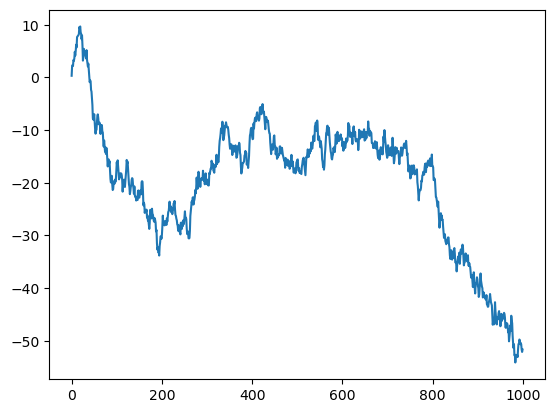

In [27]:
import matplotlib.pyplot as plt

data=pd.Series(np.random.randn(1000),index=np.arange(1000))
data=data.cumsum()
data.plot()
plt.show()

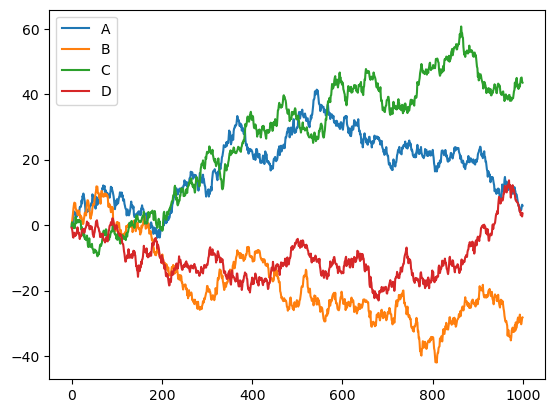

In [29]:
data=pd.DataFrame(np.random.randn(1000,4),
                  index=np.arange(1000),
                  columns=list("ABCD"))
data=data.cumsum()
data.plot()
plt.show()